# Persistent Homology — Fire Hydrant Coverage in LA County

Applies the same TDA pipeline from `tda_fire_stations_ph.ipynb` to the
**60,295 fire hydrant** point cloud.

### Key difference from the fire stations analysis
60k points makes a full Vietoris-Rips complex computationally intractable
(memory scales as O(n²) for the distance matrix). We handle this with:

1. **Grid subsampling** — thin the point cloud to ~1 point per grid cell
   (default 500 m grid) before Rips. Preserves spatial structure.
2. **Witness complex** — use MaxMin landmarks over the *full* 60k set;
   the witnesses capture fine-grained coverage gaps that subsampling misses.

### Topological interpretation
| Feature | Meaning for hydrants |
|---|---|
| **H0** long bar | Isolated hydrant cluster far from others → coverage gap at street level |
| **H1** long bar | Loop of hydrants encircling a region with none inside → fire-suppression void |

### Pipeline
1. Imports & config  
2. Load data  
3. Clip to LA County & project to UTM  
4. Grid subsampling  
5. Vietoris-Rips PH on subsample  
6. Witness complex PH on full point cloud  
7. Persistence statistics  
8. Betti numbers at operational radii  
9. Significant H1 void detection  
10. Spatial localisation → neighborhoods  
11. Neighborhood vulnerability scoring  
12. Visualisation  
13. Export

## Step 1 — Imports & Configuration

In [19]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import geopandas as gpd
import gudhi
from shapely.geometry import Point
from shapely.ops import unary_union
from scipy.spatial.distance import pdist, squareform, cdist
from pyproj import Transformer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Paths ──
HYDRANTS_PATH  = "../../data/Fire_Hydrants.geojson"
LA_COUNTY_PATH = "../../data/la_county.geojson"

# ── Grid subsampling resolution ──
# 200 m → keeps ~1 hydrant per 200×200 m cell
# Decrease for finer resolution (more points, slower Rips)
GRID_CELL_M = 500   # 500 m grid → ~3,000–4,000 points, safe for Rips

# ── Rips filtration ceiling ──
# Hydrant spacing is much finer than fire stations
# 2 km captures local street-level gaps
# 8 km captures neighbourhood-scale voids
RIPS_MAX_M = 5_000    # 5 km on subsampled cloud

# ── Witness complex ──
N_LANDMARKS = 200     # landmarks over full 60k cloud

# ── Operational evaluation radii (metres) ──
# NFPA 291: hydrant spacing ≤ 150 m in high-hazard areas
# ISO: max 300 m for residential, 150 m for commercial
EVAL_RADII_M = [100, 150, 200, 300, 500, 1000, 2000]

# ── H1 significance threshold ──
H1_SIG_THRESHOLD_M = 300   # 300 m minimum persistence

# ── CRS ──
CRS_WGS84 = "EPSG:4326"
CRS_UTM   = "EPSG:32611"   # UTM Zone 11N

print("Configuration loaded.")

Configuration loaded.


## Step 2 — Load Data

In [20]:
hydrants  = gpd.read_file(HYDRANTS_PATH).set_crs(CRS_WGS84, allow_override=True)
la_county = gpd.read_file(LA_COUNTY_PATH).set_crs(CRS_WGS84, allow_override=True)

print(f"Hydrants loaded      : {len(hydrants):,}")
print(f"Neighborhoods loaded : {len(la_county)}")
hydrants.head(3)

Hydrants loaded      : 60,295
Neighborhoods loaded : 272


,objectid,hydrantid,geometry
0,1,7726.0,POINT (-118.28914 33.98814)
1,2,82228.0,POINT (-118.17835 34.08972)
2,3,10859.0,POINT (-118.27587 34.08153)


## Step 3 — Clip to LA County & Project to UTM

Clip hydrants to the LA County boundary, then project to UTM Zone 11N
so distances are in metres — required for meaningful filtration values.

In [21]:
# Clip
county_boundary  = unary_union(la_county.geometry)
hydrants_clipped = hydrants[hydrants.geometry.within(county_boundary)].copy()
hydrants_clipped = hydrants_clipped.reset_index(drop=True)

print(f"Hydrants after clip  : {len(hydrants_clipped):,}")
print(f"Removed outside county: {len(hydrants) - len(hydrants_clipped):,}")

# Project
hydrants_proj = hydrants_clipped.to_crs(CRS_UTM)
county_proj   = la_county.to_crs(CRS_UTM)

# Full coordinate array (metres)
coords_full = np.column_stack([
    hydrants_proj.geometry.x,
    hydrants_proj.geometry.y
])

ext = coords_full.max(0) - coords_full.min(0)
print(f"Spatial extent : {ext[0]/1000:.1f} km (E–W)  ×  {ext[1]/1000:.1f} km (N–S)")
print(f"Point cloud    : {coords_full.shape[0]:,} points")

Hydrants after clip  : 59,770
Removed outside county: 525
Spatial extent : 47.1 km (E–W)  ×  70.2 km (N–S)
Point cloud    : 59,770 points


## Step 4 — Grid Subsampling

60,295 points is too large for Vietoris-Rips (O(n²) distance matrix
≈ 3.6 billion pairs). We thin the cloud by keeping **one representative
point per grid cell** — the point closest to each cell centre.

This preserves the spatial topology while reducing the point count
to a tractable size for Rips.

In [22]:
def grid_subsample(coords_m: np.ndarray, cell_size_m: float) -> np.ndarray:
    """
    Keep one point per grid cell (the point nearest the cell centre).

    Parameters
    ----------
    coords_m   : (N, 2) array in metres
    cell_size_m: grid cell edge length in metres

    Returns
    -------
    (M, 2) subsampled array, M << N
    """
    # Assign each point to a grid cell
    origin   = coords_m.min(axis=0)
    cell_idx = ((coords_m - origin) / cell_size_m).astype(int)
    cell_keys = cell_idx[:, 0] * 100_000 + cell_idx[:, 1]   # unique cell id

    # For each cell pick the point closest to its centre
    kept = []
    for key in np.unique(cell_keys):
        mask   = cell_keys == key
        pts    = coords_m[mask]
        centre = pts.mean(axis=0)
        nearest = pts[np.argmin(np.linalg.norm(pts - centre, axis=1))]
        kept.append(nearest)

    return np.array(kept)

coords_sub = grid_subsample(coords_full, GRID_CELL_M)

print(f"Full point cloud      : {len(coords_full):,} points")
print(f"After {GRID_CELL_M} m grid sub  : {len(coords_sub):,} points")
print(f"Reduction ratio       : {len(coords_full)/len(coords_sub):.1f}×")

Full point cloud      : 59,770 points
After 500 m grid sub  : 4,524 points
Reduction ratio       : 13.2×


## Step 5 — Vietoris-Rips Persistent Homology (Subsampled Cloud)

Build R(X, ε) on the subsampled point cloud up to `RIPS_MAX_M`.
At hydrant scale, even 5 km captures multiple neighbourhood-level voids.

In [23]:
print(f"Building Rips complex: N={len(coords_sub):,}, max_ε={RIPS_MAX_M/1000:.1f} km ...")

rips_complex = gudhi.RipsComplex(points=coords_sub, max_edge_length=RIPS_MAX_M)
st_rips      = rips_complex.create_simplex_tree(max_dimension=2)

print(f"  Simplices : {st_rips.num_simplices():,}")
print(f"  Vertices  : {st_rips.num_vertices():,}")

st_rips.compute_persistence(homology_coeff_field=2, min_persistence=0)
print("Persistence computed.")

Building Rips complex: N=4,524, max_ε=5.0 km ...
  Simplices : 27,660,662
  Vertices  : 4,524
Persistence computed.


In [24]:
def extract_diagrams(st):
    """Parse a GUDHI SimplexTree into H0 / H1 birth-death pairs."""
    H0, H0_inf, H1, H1_inf = [], [], [], []
    for dim, (b, d) in st.persistence():
        if dim == 0:
            (H0_inf if np.isinf(d) else H0).append((b, d))
        elif dim == 1:
            (H1_inf if np.isinf(d) else H1).append((b, d))
    return {"H0": H0, "H0_inf": H0_inf, "H1": H1, "H1_inf": H1_inf}

diag_rips = extract_diagrams(st_rips)

print(f"H0 finite pairs   : {len(diag_rips['H0'])}")
print(f"H0 essential (∞)  : {len(diag_rips['H0_inf'])}  ← connected clusters at max ε")
print(f"H1 finite pairs   : {len(diag_rips['H1'])}")
print(f"H1 essential (∞)  : {len(diag_rips['H1_inf'])}")

H0 finite pairs   : 4523
H0 essential (∞)  : 1  ← connected clusters at max ε
H1 finite pairs   : 3194
H1 essential (∞)  : 0


## Step 6 — Witness Complex PH (Full 60k Cloud)

The Witness complex uses the **full 60,295-point cloud** as witnesses
and a small set of MaxMin landmarks. This captures fine-grained gaps
that the subsampled Rips may miss, while remaining computationally feasible.

In [25]:
def maxmin_landmarks(pts, n, seed=42):
    """
    Greedy MaxMin on pts using incremental min-distance tracking.
    No full distance matrix — O(n * k) instead of O(n²).
    """
    rng     = np.random.default_rng(seed)
    idx     = [int(rng.integers(len(pts)))]
    min_d   = np.full(len(pts), np.inf)   # min dist to current landmark set

    for _ in range(n - 1):
        # Update min distances with the latest landmark only
        d_new  = np.linalg.norm(pts - pts[idx[-1]], axis=1)
        min_d  = np.minimum(min_d, d_new)
        idx.append(int(np.argmax(min_d)))

    return np.array(idx)

# ── Run MaxMin on the SUBSAMPLED cloud (not the full 60k) ──
lm_idx    = maxmin_landmarks(coords_sub, N_LANDMARKS)
landmarks = coords_sub[lm_idx]

print(f"Landmarks : {len(landmarks)} (MaxMin over {len(coords_sub):,} subsampled points)")
print(f"Building Witness complex (max_α={RIPS_MAX_M/1000:.1f} km) ...")

wc     = gudhi.EuclideanWitnessComplex(witnesses=coords_sub, landmarks=landmarks)
st_wit = wc.create_simplex_tree(max_alpha_square=RIPS_MAX_M**2, limit_dimension=2)

print(f"  Simplices : {st_wit.num_simplices():,}")
st_wit.compute_persistence(homology_coeff_field=2, min_persistence=0)

diag_wit = extract_diagrams(st_wit)

Landmarks : 200 (MaxMin over 4,524 subsampled points)
Building Witness complex (max_α=5.0 km) ...
  Simplices : 21,097


## Step 7 — Persistence Statistics

Persistence entropy H = −Σ pᵢ log pᵢ where pᵢ = persistenceᵢ / Σ persistenceⱼ  
High entropy → uniform coverage; Low entropy → dominated by a few large voids.

In [26]:
def persistence_stats(diags, label):
    rows = []
    for key in ("H0", "H1"):
        pairs = diags[key]
        if not pairs:
            continue
        arr  = np.array(pairs)
        pers = arr[:, 1] - arr[:, 0]
        p    = pers / pers.sum() if pers.sum() > 0 else pers
        rows.append({
            "complex"        : label,
            "dimension"      : key,
            "n_features"     : len(pairs),
            "pers_mean_m"    : round(pers.mean(), 2),
            "pers_max_m"     : round(pers.max(), 2),
            "pers_std_m"     : round(pers.std(), 2),
            "pers_entropy"   : round(float(-np.sum(p * np.log(p + 1e-12))), 4),
        })
    return pd.DataFrame(rows)

stats = pd.concat([
    persistence_stats(diag_rips, f"Rips ({GRID_CELL_M}m grid)"),
    persistence_stats(diag_wit,  f"Witness ({N_LANDMARKS} landmarks)"),
], ignore_index=True)

stats

,complex,dimension,n_features,pers_mean_m,pers_max_m,pers_std_m,pers_entropy
0,Rips (500m grid),H0,4523,425.17,1791.16,80.01,8.3986
1,Rips (500m grid),H1,3194,117.02,2827.58,121.65,7.7667
2,Witness (200 landmarks),H1,33,1397657.64,10173423.22,2102133.13,2.7772


## Step 8 — Betti Numbers at Operational Radii

Evaluate β₀ (clusters) and β₁ (voids) at radii matching hydrant standards:
- **150 m** — NFPA 291 max spacing in high-hazard zones
- **300 m** — ISO residential spacing limit
- **500 m–2 km** — neighbourhood-scale gaps

In [27]:
def betti_at_radii(diags, radii_m, label):
    def alive(pairs, inf_pairs, eps):
        return (sum(1 for b, d in pairs     if b <= eps <= d) +
                sum(1 for b, d in inf_pairs if eps >= b))
    rows = []
    for eps in radii_m:
        rows.append({
            "complex"   : label,
            "radius_m"  : eps,
            "beta0"     : alive(diags["H0"], diags["H0_inf"], eps),
            "beta1"     : alive(diags["H1"], diags.get("H1_inf", []), eps),
        })
    return pd.DataFrame(rows)

betti_rips = betti_at_radii(diag_rips, EVAL_RADII_M, f"Rips ({GRID_CELL_M}m grid)")
betti_wit  = betti_at_radii(diag_wit,  EVAL_RADII_M, f"Witness ({N_LANDMARKS} landmarks)")

print("=== Vietoris-Rips ===")
print(betti_rips.to_string(index=False))
print()
print("=== Witness ===")
print(betti_wit.to_string(index=False))

=== Vietoris-Rips ===
         complex  radius_m  beta0  beta1
Rips (500m grid)       100   4521      0
Rips (500m grid)       150   4513      0
Rips (500m grid)       200   4469      0
Rips (500m grid)       300   4208      0
Rips (500m grid)       500    579    280
Rips (500m grid)      1000      2     45
Rips (500m grid)      2000      1     10

=== Witness ===
                complex  radius_m  beta0  beta1
Witness (200 landmarks)       100      1     32
Witness (200 landmarks)       150      1     32
Witness (200 landmarks)       200      1     32
Witness (200 landmarks)       300      1     32
Witness (200 landmarks)       500      1     32
Witness (200 landmarks)      1000      1     32
Witness (200 landmarks)      2000      1     32


## Step 9 — Significant H1 Voids

Filter H1 pairs by persistence ≥ `H1_SIG_THRESHOLD_M`.
Each surviving feature is a region encircled by hydrants but with
none inside — a fire-suppression coverage void.

In [28]:
def significant_h1(diags, threshold_m):
    sig = [(b, d, d - b) for b, d in diags["H1"] if (d - b) >= threshold_m]
    return sorted(sig, key=lambda x: -x[2])

sig_h1 = significant_h1(diag_rips, H1_SIG_THRESHOLD_M)

print(f"Significant H1 voids (persistence ≥ {H1_SIG_THRESHOLD_M} m): {len(sig_h1)}")
print()
print(f"{'Rank':>4}  {'Birth (m)':>9}  {'Death (m)':>9}  {'Persistence (m)':>15}")
print("-" * 44)
for i, (b, d, p) in enumerate(sig_h1, 1):
    print(f"{i:>4}  {b:>9.1f}  {d:>9.1f}  {p:>15.1f}")

Significant H1 voids (persistence ≥ 300 m): 81

Rank  Birth (m)  Death (m)  Persistence (m)
--------------------------------------------
   1      534.1     3361.7           2827.6
   2      520.1     2434.0           1914.0
   3     1485.3     3342.1           1856.9
   4      579.7     2206.7           1627.1
   5      579.9     2201.6           1621.6
   6      728.4     2332.6           1604.1
   7      657.6     2128.2           1470.5
   8     1095.2     2387.7           1292.5
   9      724.6     1813.6           1089.0
  10      560.3     1605.2           1044.9
  11      727.8     1647.2            919.5
  12      841.4     1662.6            821.2
  13      523.2     1342.4            819.2
  14      814.4     1599.8            785.4
  15      528.6     1278.7            750.1
  16      756.2     1446.8            690.6
  17      562.6     1237.3            674.8
  18      563.1     1209.9            646.8
  19      646.3     1285.7            639.5
  20      549.1     1177.5 

## Step 10 — Spatial Localisation of Voids

For each significant H1 void:
1. Sample a 200 m grid inside LA County
2. Find the grid point with maximum distance to nearest hydrant
   that falls within the void's (birth, death) band
3. Look up which neighborhood polygon contains that point

In [29]:
def localise_voids(sig_h1, hydrants_proj, county_proj, coords_m,
                   grid_step_m=1000):       # coarser grid: 1 km instead of 200 m
    county_union = unary_union(county_proj.geometry)
    t_back       = Transformer.from_crs(CRS_UTM, CRS_WGS84, always_xy=True)

    # Build grid inside county
    minx, miny, maxx, maxy = county_union.bounds
    gx, gy   = np.arange(minx, maxx, grid_step_m), np.arange(miny, maxy, grid_step_m)
    GX, GY   = np.meshgrid(gx, gy)
    grid_pts = np.column_stack([GX.ravel(), GY.ravel()])
    inside   = np.array([county_union.contains(Point(p)) for p in grid_pts])
    grid_in  = grid_pts[inside]

    print(f"Grid points inside county: {len(grid_in):,}")

    # ── Chunked nearest-hydrant distance to avoid memory crash ──
    def min_dist_to_hydrants(query_pts, hydrant_pts, chunk_size=500):
        """Compute min distance from each query point to any hydrant, in chunks."""
        min_dists = np.full(len(query_pts), np.inf)
        for start in range(0, len(query_pts), chunk_size):
            end   = min(start + chunk_size, len(query_pts))
            chunk = cdist(query_pts[start:end], hydrant_pts)
            min_dists[start:end] = chunk.min(axis=1)
        return min_dists

    D_stn = min_dist_to_hydrants(grid_in, coords_m)

    rows = []
    for rank, (birth, death, pers) in enumerate(sig_h1, 1):
        mid  = (birth + death) / 2
        tol  = pers * 0.4
        mask = (D_stn >= mid - tol) & (D_stn <= mid + tol)
        cands = grid_in[mask] if mask.any() else grid_in

        # Chunked again for candidate distances
        d_cands  = min_dist_to_hydrants(cands, coords_m)
        centre_m = cands[np.argmax(d_cands)]
        cx, cy   = centre_m

        hood = "Outside named neighborhoods"
        for _, row in county_proj.iterrows():
            if row.geometry.contains(Point(cx, cy)):
                hood = row.get("name", "Unknown")
                break

        lon, lat = t_back.transform(cx, cy)
        rows.append({
            "rank"          : rank,
            "birth_m"       : round(birth, 1),
            "death_m"       : round(death, 1),
            "persistence_m" : round(pers, 1),
            "neighborhood"  : hood,
            "void_lon"      : round(lon, 6),
            "void_lat"      : round(lat, 6),
            "approx_area_m2": round(np.pi * mid**2, 0),
        })
    return pd.DataFrame(rows)

void_df = localise_voids(sig_h1, hydrants_proj, county_proj, coords_full)
void_df

Grid points inside county: 10,397


,rank,birth_m,death_m,persistence_m,neighborhood,void_lon,void_lat,approx_area_m2
0,1,534.1,3361.7,2827.6,Carson,-118.249089,33.876327,11920066.0
1,2,520.1,2434.0,1914.0,Pacific Palisades,-118.545021,34.098414,6853944.0
2,3,1485.3,3342.1,1856.9,South Gate,-118.196044,33.949000,18302866.0
3,4,579.7,2206.7,1627.1,Carson,-118.259767,33.867200,6097856.0
4,5,579.9,2201.6,1621.6,Santa Clarita,-118.517029,34.351251,6076460.0
...,...,...,...,...,...,...,...,...
76,77,522.3,826.4,304.1,Beverly Hills,-118.403536,34.064041,1428756.0
77,78,524.7,828.2,303.6,Lynwood,-118.217426,33.930753,1437494.0
78,79,592.2,895.2,303.0,Huntington Park,-118.229151,33.993764,1737512.0
79,80,625.0,927.0,302.0,Inglewood,-118.358764,33.974365,1891748.0


## Step 11 — Neighborhood Vulnerability Scoring

Each neighborhood scored on:

| Component | Weight | Rationale |
|---|---|---|
| Min distance to nearest hydrant | 50% | Direct suppression access gap |
| Local β₁ at that distance | 30% | Topological void context |
| 1 − hydrant density (500 m radius) | 20% | Structural under-coverage |

In [30]:
def score_neighborhoods(hydrants_proj, county_proj, coords_m, diag_rips,
                         eval_radius_m=500):
    county_c = county_proj.copy()
    county_c["centroid"] = county_c.geometry.centroid

    rows = []
    for _, row in county_c.iterrows():
        cx, cy     = row["centroid"].x, row["centroid"].y
        centroid_m = np.array([cx, cy])
        dists      = np.sqrt(((coords_m - centroid_m)**2).sum(1))

        min_dist   = dists.min()
        n_nearby   = int((dists <= eval_radius_m).sum())
        area_km2   = row.geometry.area / 1e6
        density    = n_nearby / max(area_km2, 0.01)
        local_b1   = sum(1 for b, d in diag_rips["H1"] if b <= min_dist <= d)

        rows.append({
            "neighborhood"        : row.get("name", "Unknown"),
            "area_km2"            : round(area_km2, 3),
            "min_hydrant_dist_m"  : round(min_dist, 1),
            "n_hydrants_500m"     : n_nearby,
            "hydrant_density_km2" : round(density, 2),
            "local_beta1"         : local_b1,
        })

    df = pd.DataFrame(rows)

    def n01(s):
        r = s.max() - s.min()
        return (s - s.min()) / r if r > 0 else s * 0

    df["coverage_gap_score"] = (
        0.50 * n01(df["min_hydrant_dist_m"]) +
        0.30 * n01(df["local_beta1"]) +
        0.20 * (1 - n01(df["hydrant_density_km2"]))
    ).round(4)

    return df.sort_values("coverage_gap_score", ascending=False).reset_index(drop=True)

vuln_df = score_neighborhoods(hydrants_proj, county_proj, coords_full, diag_rips)

print("Top 20 most vulnerable neighborhoods (hydrant coverage):")
vuln_df.head(20)[["neighborhood", "min_hydrant_dist_m",
                   "n_hydrants_500m", "local_beta1", "coverage_gap_score"]]

Top 20 most vulnerable neighborhoods (hydrant coverage):


,neighborhood,min_hydrant_dist_m,n_hydrants_500m,local_beta1,coverage_gap_score
0,Northeast Antelope Valley,60321.3,0,0,0.7000
1,Lake Los Angeles,56103.4,0,0,0.6650
2,Northwest Antelope Valley,47436.1,0,0,0.5932
3,Lancaster,45792.4,0,0,0.5796
4,Sun Village,43717.0,0,0,0.5624
5,Southeast Antelope Valley,41882.2,0,0,0.5471
6,Avalon,41453.8,0,0,0.5436
7,Claremont,40232.8,0,0,0.5335
8,Palmdale,40171.3,0,0,0.5330
9,Quartz Hill,40083.4,0,0,0.5322


## Step 12 — Visualisation

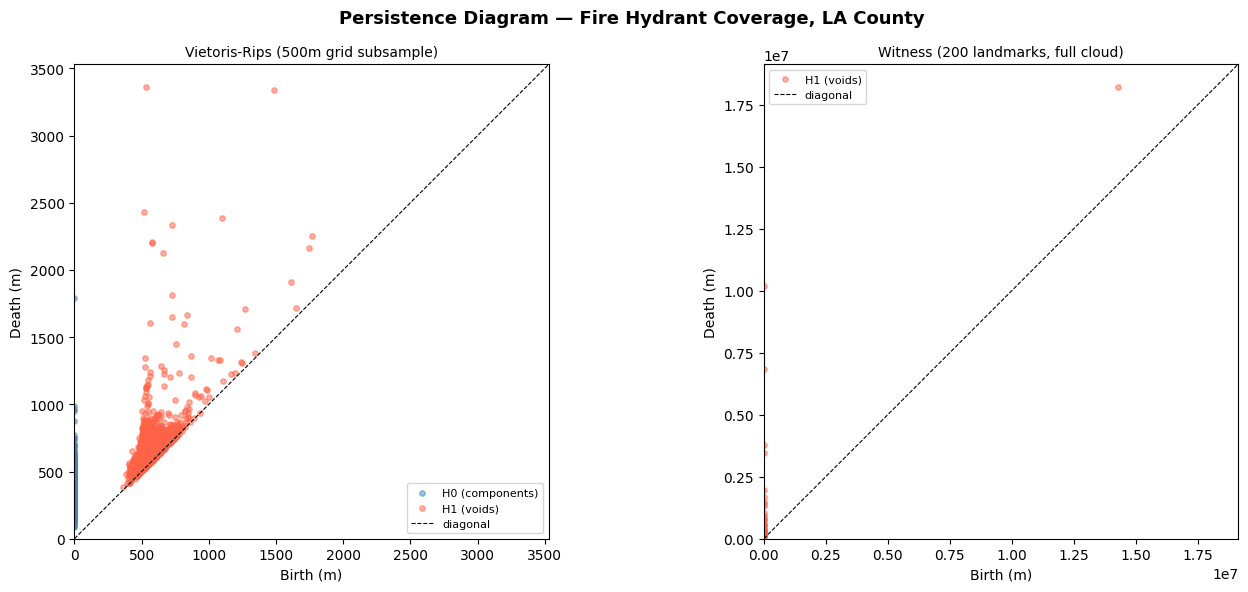

In [31]:
# ── 12a. Persistence Diagram ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, diags, title in zip(
    axes,
    [diag_rips, diag_wit],
    [f"Vietoris-Rips ({GRID_CELL_M}m grid subsample)",
     f"Witness ({N_LANDMARKS} landmarks, full cloud)"]
):
    max_val = 0
    for key, color, label in [
        ("H0", "steelblue", "H0 (components)"),
        ("H1", "tomato",    "H1 (voids)"),
    ]:
        pairs = diags[key]
        if pairs:
            arr = np.array(pairs)
            ax.scatter(arr[:, 0], arr[:, 1], c=color, alpha=0.5,
                       s=15, label=label)
            max_val = max(max_val, arr.max())

    lim = max_val * 1.05 if max_val > 0 else RIPS_MAX_M
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="diagonal")
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Birth (m)"); ax.set_ylabel("Death (m)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8); ax.set_aspect("equal")

plt.suptitle("Persistence Diagram — Fire Hydrant Coverage, LA County",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../../results/FireHydrants_persistence_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

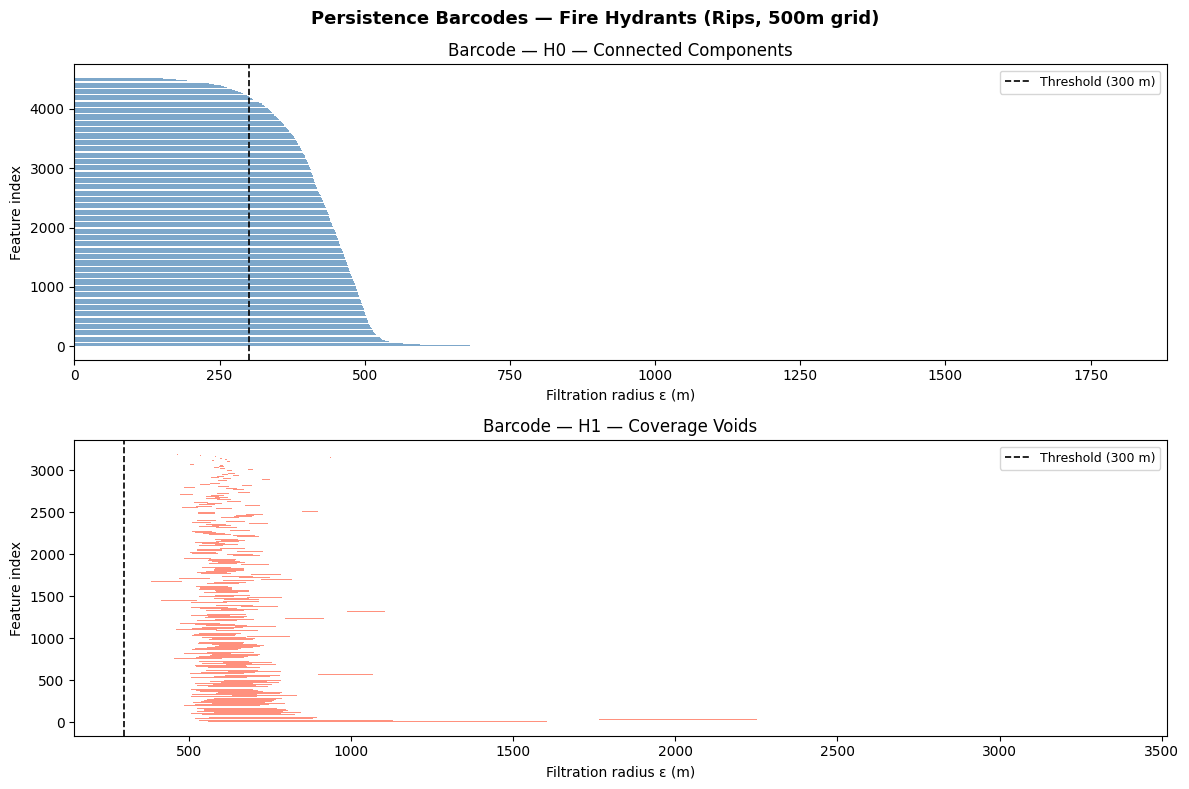

Saved: FireHydrants_barcodes.png


In [32]:
# ── 12b. Barcode Plot ──
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
colors = {"H0": "steelblue", "H1": "tomato"}
labels = {"H0": "H0 — Connected Components", "H1": "H1 — Coverage Voids"}

for ax, key in zip(axes, ["H0", "H1"]):
    pairs = sorted(diag_rips[key], key=lambda x: x[1]-x[0], reverse=True)
    for i, (b, d) in enumerate(pairs):
        ax.barh(i, d - b, left=b, color=colors[key], alpha=0.7, height=0.8)
    ax.axvline(H1_SIG_THRESHOLD_M, color="black", linestyle="--", lw=1.2,
               label=f"Threshold ({H1_SIG_THRESHOLD_M} m)")
    ax.set_xlabel("Filtration radius ε (m)")
    ax.set_ylabel("Feature index")
    ax.set_title(f"Barcode — {labels[key]}")
    ax.legend(fontsize=9)

plt.suptitle(f"Persistence Barcodes — Fire Hydrants (Rips, {GRID_CELL_M}m grid)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../../results/FireHydrants_barcodes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: FireHydrants_barcodes.png")

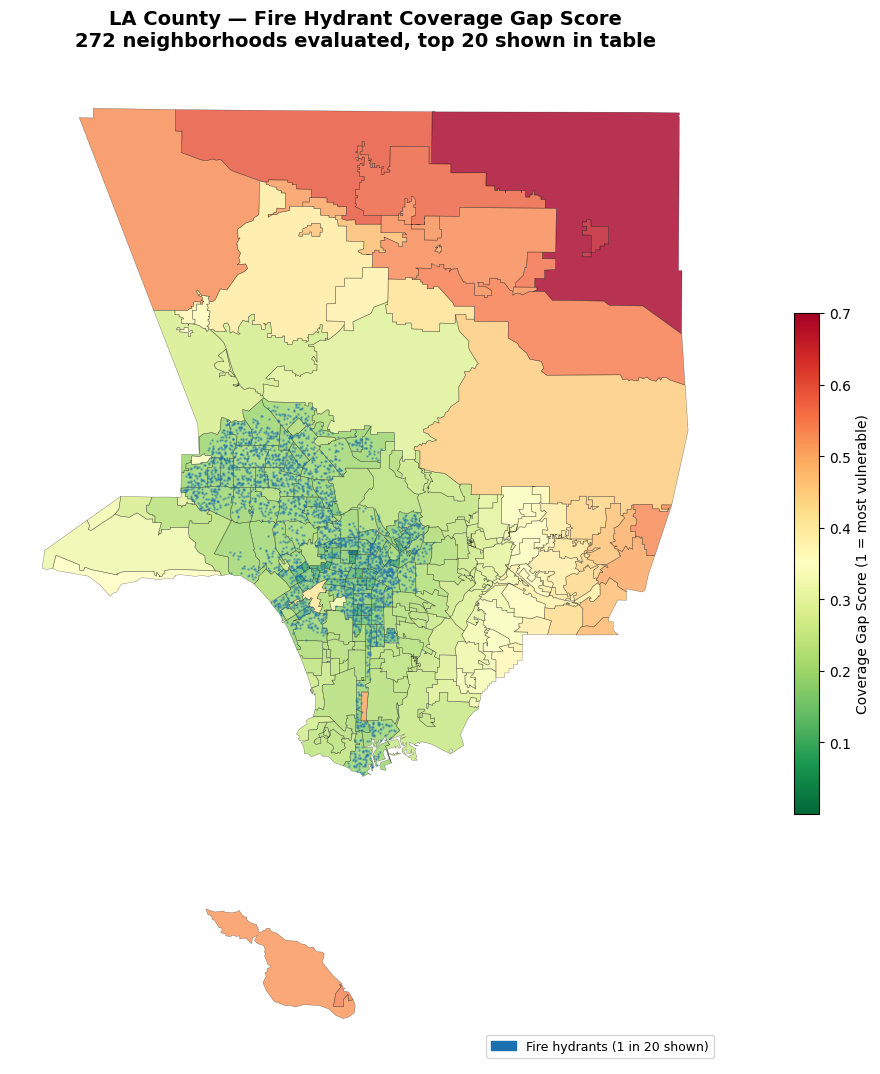

Saved: hydrant_vulnerability_map.png


In [33]:
# ── 12c. Vulnerability Choropleth ──
fig, ax = plt.subplots(figsize=(15, 11))

merged = county_proj.merge(
    vuln_df[["neighborhood", "coverage_gap_score"]],
    left_on="name", right_on="neighborhood", how="left"
)
merged["coverage_gap_score"] = merged["coverage_gap_score"].fillna(0)

merged.plot(column="coverage_gap_score", ax=ax, cmap="RdYlGn_r",
            legend=True, alpha=0.80,
            legend_kwds={"label": "Coverage Gap Score (1 = most vulnerable)",
                         "shrink": 0.5})

# Subsample hydrant points for display (plot every 20th to avoid overplotting)
hydrants_display = hydrants_proj.iloc[::20]
hydrants_display.plot(ax=ax, color="#1a6faf", markersize=0.8,
                      alpha=0.4, zorder=5)

county_proj.boundary.plot(ax=ax, color="black", linewidth=0.3, alpha=0.5)

patches = [mpatches.Patch(color="#1a6faf", label="Fire hydrants (1 in 20 shown)")]
ax.legend(handles=patches, fontsize=9, loc="lower right")

ax.set_title(
    f"LA County — Fire Hydrant Coverage Gap Score\n"         # fix 2: \n instead of raw newline
    f"{len(vuln_df)} neighborhoods evaluated, top 20 shown in table",
    fontsize=14, fontweight="bold", pad=12
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("../../results/FireHydrants_vulnerability_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: hydrant_vulnerability_map.png")

## Step 13 — Export Results

In [34]:
# void_df.to_csv("hydrant_coverage_voids.csv", index=False)
# vuln_df.to_csv("hydrant_neighborhood_vulnerability.csv", index=False)
# betti_rips.to_csv("hydrant_betti_rips.csv", index=False)
# betti_wit.to_csv("hydrant_betti_witness.csv", index=False)
# stats.to_csv("hydrant_persistence_stats.csv", index=False)

# print("Exported:")
# print("  hydrant_coverage_voids.csv              — H1 void locations")
# print("  hydrant_neighborhood_vulnerability.csv  — ranked neighborhoods")
# print("  hydrant_betti_rips.csv                  — β0, β1 at key radii (Rips)")
# print("  hydrant_betti_witness.csv               — β0, β1 at key radii (Witness)")
# print("  hydrant_persistence_stats.csv           — persistence statistics")
# print("  hydrant_persistence_diagram.png")
# print("  hydrant_barcodes.png")
# print("  hydrant_vulnerability_map.png")